1.1 IMPORTAÇÃO DAS BIBLIOTECAS

In [4]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   

1.2 CARREGAMENTO DOS DADOS

In [5]:
# carregar dos dados do arquivo CSV
dados = pd.read_csv('/Users/felipe_feliciano/Documents/superstore-analysis/data/Sample - Superstore.csv', encoding='latin-1')

In [6]:
# primeiras linhas do DataFrame
dados.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
# informações sobre o DataFrame
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
# estatísticas descritivas do DataFrame 
dados.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


1.3 INSPEÇÃO GERAL DOS DADOS

In [9]:
# tipos de dados de cada coluna
dados.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [10]:
# verificar se há valores nulos
dados.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [11]:
duplicadas = dados.duplicated().sum()
print(f'Número de linhas duplicadas: {duplicadas}')

Número de linhas duplicadas: 0


1.4 CONVERSÃO DE DADOS

In [12]:
dados = dados.drop_duplicates()
print(f'Número de linhas após remover duplicatas: {dados.shape[0]}')

Número de linhas após remover duplicatas: 9994


In [13]:
# converter as colunas de data para o formato datetime
dados['Order Date'] = pd.to_datetime(dados['Order Date'], dayfirst=False)
dados['Ship Date'] = pd.to_datetime(dados['Ship Date'])
print('Tipos de data apos conversão:')
print(dados[['Order Date', 'Ship Date']].dtypes)

Tipos de data apos conversão:
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [14]:
# Criar coluna de Ano e Trimestre a partir da data do pedido
dados['Year'] = dados['Order Date'].dt.year # seleciona o ano da data do pedido
dados['Quarter'] = dados['Order Date'].dt.quarter  # seleciona o trimestre do ano
dados['Month'] = dados['Order Date'].dt.month # seleciona o mês da data do pedido
dados['Year_Quarter'] = dados['Year'].astype(str) + '-T' + dados['Quarter'].astype(str) # combina ano e trimestre em uma nova coluna

print('Anos disponíveis no dataset:')
print(sorted(dados['Year'].unique()))

Anos disponíveis no dataset:
[np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]


In [15]:
# Criar coluna de dias de entrega
dados['Delivery Days'] = (dados['Ship Date'] - dados['Order Date']).dt.days # calcula a diferença em dias entre a data de envio e a data do pedido
print('Tempo medio de entrega (em dias):')
print(round(dados['Delivery Days'].mean(), 1))

Tempo medio de entrega (em dias):
4.0


In [16]:
# Criar coluna de margem de lucro percentual 
dados['Profit Margin %'] = round((dados['Profit']/ dados['Sales'])*100, 2) # calcula a margem de lucro como porcentagem das vendas
print('Margem de lucro média geral:')
print(f"{dados['Profit Margin %'].mean():.2f}%")

Margem de lucro média geral:
12.03%


In [17]:
dados['Profitable'] = dados['Profit'].apply(lambda x: 'Lucrativo'
                                            if x > 0 else 'Prejuizo') # classifica cada pedido como 'Lucrativo' ou 'Prejuizo' com base no valor do lucro
print('Distribuição:')
print(dados['Profitable'].value_counts())

Distribuição:
Profitable
Lucrativo    8058
Prejuizo     1936
Name: count, dtype: int64


In [18]:
dados.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year',
       'Quarter', 'Month', 'Year_Quarter', 'Delivery Days', 'Profit Margin %',
       'Profitable'],
      dtype='object')

2.1 VISÃO GERAL DOS NUMEROS PRINCIPAIS

In [19]:
# KPIS GERAIS DO NEGOCIO
total_vendas = dados['Sales'].sum() # calcula o total de vendas somando a coluna 'Sales'
total_lucro = dados['Profit'].sum() # calcula o total de lucro somando a coluna 'Profit'
margem_media = dados['Profit Margin %'].mean() # calcula a margem de lucro média
total_pedidos = dados['Order ID'].nunique() # calcula o total de pedidos únicos
ticket_medio = total_vendas / total_pedidos # calcula o ticket médio

print('=' * 40)
print('       KPIs GERAIS DO NEGÓCIO')
print('=' * 40)
print(f'  Total de Vendas:    $ {total_vendas:,.2f}')
print(f'  Total de Lucro:     $ {total_lucro:,.2f}')
print(f'  Margem de Lucro Média: {margem_media:.2f}%')
print(f'  Total de Pedidos:     {total_pedidos:,}')
print(f'  Ticket Médio:       $ {ticket_medio:,.2f}')
print('=' * 40)

       KPIs GERAIS DO NEGÓCIO
  Total de Vendas:    $ 2,297,200.86
  Total de Lucro:     $ 286,397.02
  Margem de Lucro Média: 12.03%
  Total de Pedidos:     5,009
  Ticket Médio:       $ 458.61


2.2 ANÁLISE POR CATEGORIA E SUBCATEGORIA

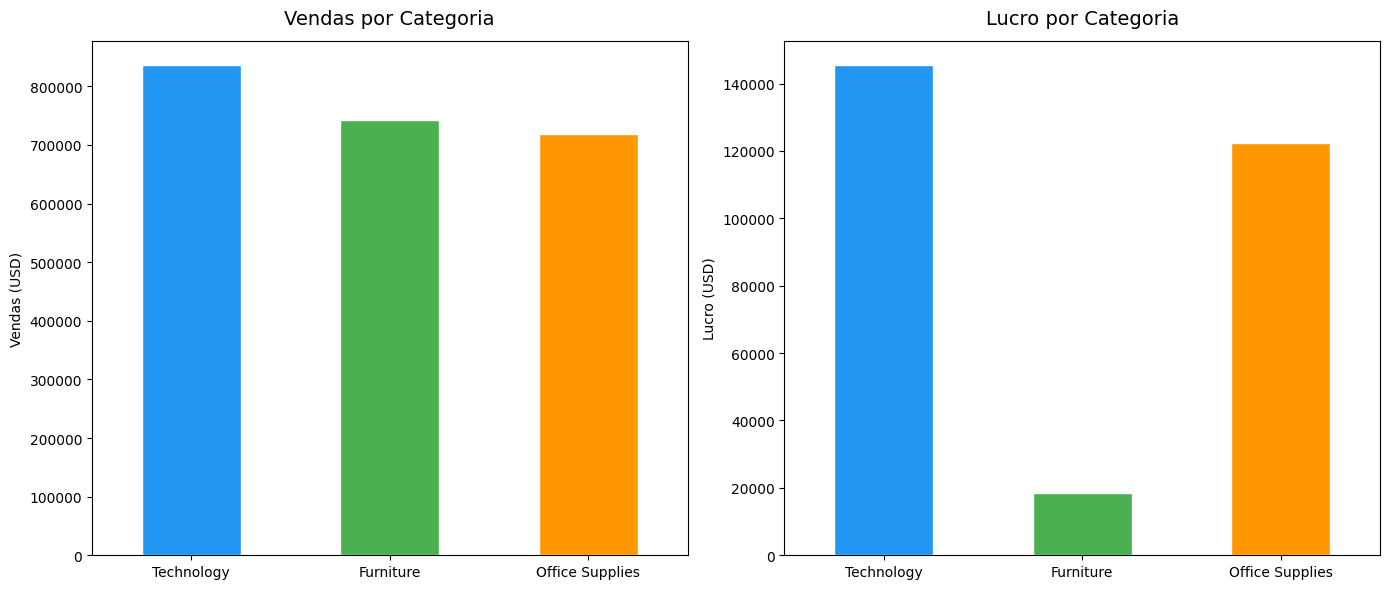

In [20]:
# grafico de vendas e lucro por categoria

categoria = dados.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False) # agrupa os dados por categoria e soma as vendas e lucros, ordenando pelo total de vendas

fig, axes = plt.subplots(1,2, figsize=(14,6)) # cria uma figura com 1 linha e 2 colunas para os gráficos

cores = ['#2196F3', '#4CAF50', '#FF9800'] # define uma paleta de cores personalizada para as barras

categoria['Sales'].plot(kind='bar', ax=axes[0], color=cores, edgecolor='white') # plota o gráfico de barras para as vendas por categoria
axes[0].set_title('Vendas por Categoria', fontsize=14, pad=12) # define o título do gráfico de vendas com um espaçamento adicional
axes[0].set_xlabel('') # remove o rótulo do eixo x para o gráfico de vendas
axes[0].set_ylabel('Vendas (USD)') # define o rótulo do eixo y para o gráfico de vendas
axes[0].tick_params(axis='x', rotation=0) # define a rotação dos rótulos do eixo x para o gráfico de vendas

categoria['Profit'].plot(kind='bar', ax=axes[1], color=cores, edgecolor='white') # plota o gráfico de barras para os lucros por categoria
axes[1].set_title('Lucro por Categoria', fontsize=14, pad=12) # define o título do gráfico de lucro com um espaçamento adicional
axes[1].set_xlabel('') # remove o rótulo do eixo x para o gráfico de lucro
axes[1].set_ylabel('Lucro (USD)') # define o rótulo do eixo y para o gráfico de lucro
axes[1].tick_params(axis='x', rotation=0) # define a rotação dos rótulos do eixo x para o gráfico de lucro

plt.tight_layout() # ajusta o layout para evitar sobreposição de elementos
plt.show()  

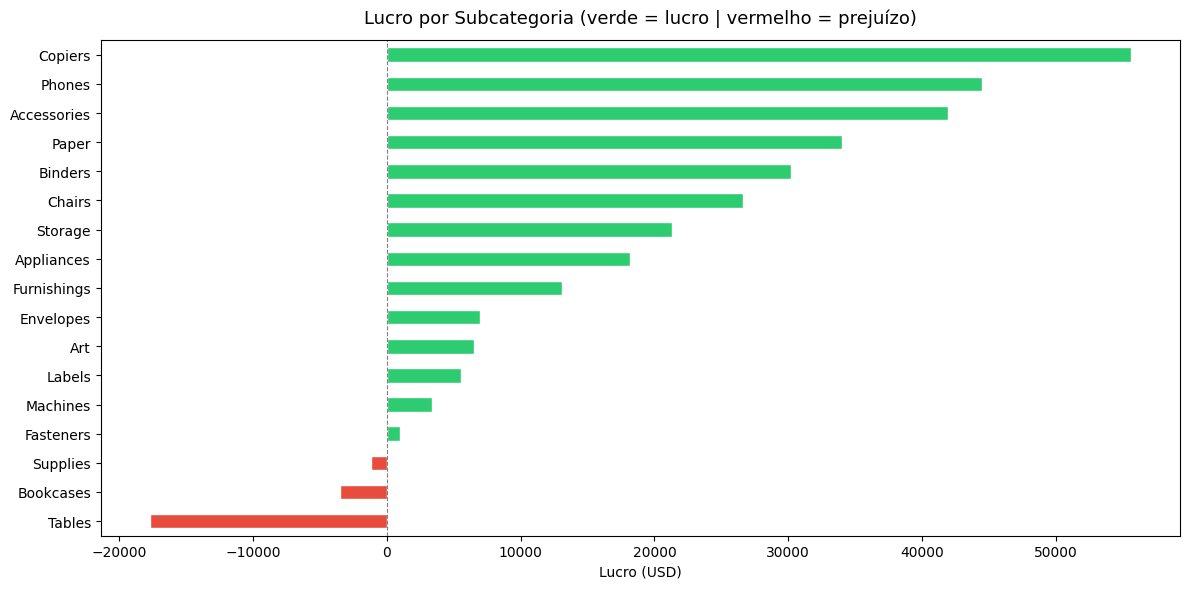

In [21]:
# Gráfico 2: Top 10 subcategorias por lucro
subcategoria = dados.groupby('Sub-Category')['Profit'].sum().sort_values() # agrupa os dados por subcategoria, soma os lucros e ordena pelo lucro total

cores_barras = ['#e74c3c' if v < 0 else '#2ecc71' for v in subcategoria] # define a cor das barras com base no valor do lucro (vermelho para prejuízo, verde para lucro)

fig, ax = plt.subplots(figsize=(12, 6)) # cria uma figura com o tamanho especificado
subcategoria.plot(kind='barh', ax=ax, color=cores_barras, edgecolor='white') # plota o gráfico de barras horizontais para as subcategorias
ax.set_title('Lucro por Subcategoria (verde = lucro | vermelho = prejuízo)', fontsize=13, pad=12) # define o título do gráfico com um espaçamento adicional
ax.set_xlabel('Lucro (USD)') # define o rótulo do eixo x
ax.set_ylabel('') # remove o rótulo do eixo y
ax.axvline(x=0, color='gray', linewidth=0.8, linestyle='--') # adiciona uma linha vertical no eixo x
plt.tight_layout() # ajusta o layout para evitar sobreposição de elementos
plt.show()

2.3 ANALISE POR REGIAO

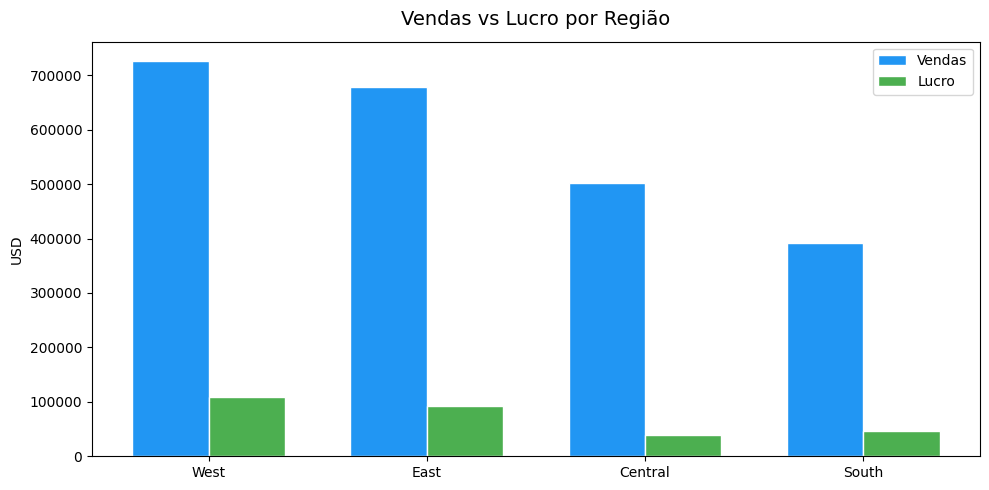

In [22]:
# Gráfico 3: Vendas vs Lucro por Região
regiao = dados.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(regiao))
largura = 0.35

barras1 = ax.bar([i - largura/2 for i in x], regiao['Sales'], largura, label='Vendas', color='#2196F3', edgecolor='white')
barras2 = ax.bar([i + largura/2 for i in x], regiao['Profit'], largura, label='Lucro', color='#4CAF50', edgecolor='white')

ax.set_title('Vendas vs Lucro por Região', fontsize=14, pad=12)
ax.set_xticks(x)
ax.set_xticklabels(regiao.index)
ax.set_ylabel('USD')
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
# Margem de lucro por região - informa aonde vende muito mas lucra pouco
margem_regiao = dados.groupby('Region').apply(
    lambda x: round((x['Profit'].sum()/ x['Sales'].sum())*100, 1)
).sort_values(ascending=False) # calcula a margem de lucro percentual por região, ordenando do maior para o menor

print('Margem de lucro por região (%):')
print(margem_regiao)

Margem de lucro por região (%):
Region
West       14.9
East       13.5
South      11.9
Central     7.9
dtype: float64


/var/folders/k3/h54mv9rj03jc53ln83wl7_0w0000gn/T/ipykernel_11858/3995581678.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  margem_regiao = dados.groupby('Region').apply(


3. RESPONDENDO AS PERGUNTAS DE NEGOCIO 

In [24]:
# PERGUNTA 1: Quais subcategorias geram prejuizo?

prejuizo = dados.groupby('Sub-Category')['Profit'].sum() # agrupa os dados por subcategoria, soma os lucros e ordena pelo lucro total
prejuizo_negativo = prejuizo[prejuizo < 0].sort_values() # filtra apenas as subcategorias com lucro negativo e ordena do mais negativo para o menos negativo
print('Subcategorias que geram prejuízo:')
for sub, valor in prejuizo_negativo.items(): # itera sobre as subcategorias e seus respectivos valores de lucro negativo, imprimindo cada um formatado como moeda
        print(f'  {sub}: $ {valor:,.2f}') 

Subcategorias que geram prejuízo:
  Tables: $ -17,725.48
  Bookcases: $ -3,472.56
  Supplies: $ -1,189.10


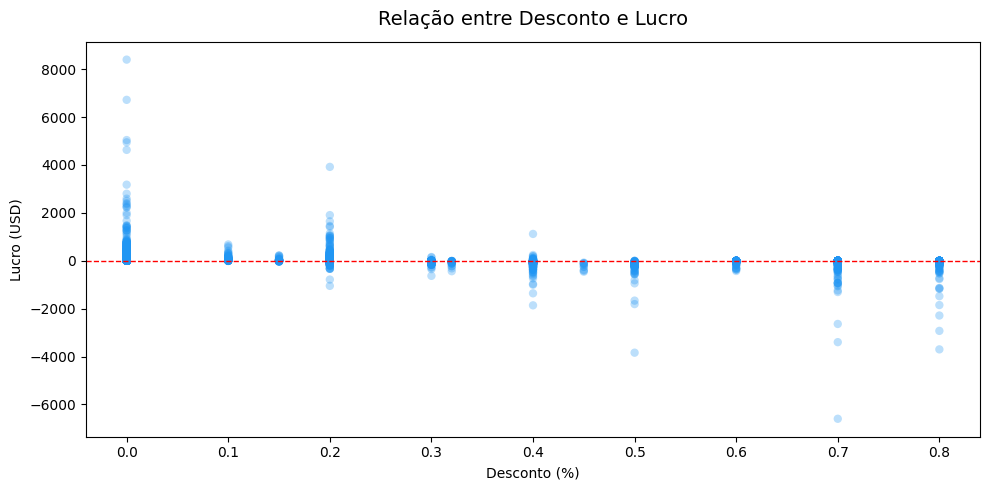

Correlação entre desconto e lucro: -0.22
(valores negativos indicam que mais desconto = menos lucro)


In [25]:
# Pergunta 2: Desconto alto prejudica o lucro?
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(dados['Discount'], dados['Profit'], alpha=0.3, color='#2196F3', edgecolors='none')
ax.axhline(y=0, color='red', linewidth=1, linestyle='--')
ax.set_title('Relação entre Desconto e Lucro', fontsize=14, pad=12)
ax.set_xlabel('Desconto (%)')
ax.set_ylabel('Lucro (USD)')
plt.tight_layout()
plt.show()

# Correlação numérica
correlacao = round(dados['Discount'].corr(dados['Profit']), 2) # calcula a correlação entre as colunas 'Desconto' e 'Lucro', multiplicando por 100 para expressar em porcentagem e arredondando para 2 casas decimais
print(f'Correlação entre desconto e lucro: {correlacao}')
print('(valores negativos indicam que mais desconto = menos lucro)')

In [26]:
# Pergunta 3: Qual segmento de cliente é mais lucrativo?

segmento = dados.groupby('Segment')[['Sales', 'Profit']].sum() # agrupa os dados por segmento, somando as vendas e os lucros para cada segmento
segmento['Margem %'] = round((segmento['Profit'] / segmento['Sales'])*100, 1) # calcula a margem de lucro percentual para cada segmento, arredondando para 1 casa decimal
segmento = segmento.sort_values('Margem %', ascending=False) # ordena o DataFrame pelo valor da margem de lucro percentual em ordem decrescente para mostrar o segmento mais lucrativo no topo  
# formartar sales e profit como moeda 
segmento['Sales'] = segmento['Sales'].apply(lambda x: f'$ {x:,.2f}') # formata a coluna 'Sales' como moeda
segmento['Profit'] = segmento['Profit'].apply(lambda x: f'$ {x:,.2f}') # formata a coluna 'Profit' como moeda

print('Lucratividade por segmento:')
print(segmento) 

Lucratividade por segmento:
                      Sales        Profit  Margem %
Segment                                            
Home Office    $ 429,653.15   $ 60,298.68      14.0
Corporate      $ 706,146.37   $ 91,979.13      13.0
Consumer     $ 1,161,401.34  $ 134,119.21      11.5


In [27]:
# Pergunta 4 : Qual cidade mais vende mas tem baixo lucro? (vendas altas mas margem baixa)

cidade = dados.groupby('City')[['Sales', 'Profit']].sum() # agrupa os dados por cidade, somando as vendas e os lucros para cada cidade
cidade['Margem %'] = round((cidade['Profit'] / cidade['Sales'])*100, 1) # calcula a margem de lucro percentual para cada cidade, arredondando para 1 casa decimal
cidade = cidade.sort_values('Sales', ascending=False) # ordena o DataFrame pelo total de vendas em ordem decrescente para mostrar as cidades que mais vendem no

# top 10 cidades por volume de vendas 
top10 = cidade.head(10).copy() # seleciona as 10 primeiras linhas do DataFrame, que correspondem às 10 cidades com maior volume de vendas

# formatar para a exibição
top10['Sales_city'] = top10['Sales'].apply(lambda x: f'$ {x:,.2f}') # formata a coluna 'Sales' como moeda
top10['Profit_city'] = top10['Profit'].apply(lambda x: f'$ {x:,.2f}') # formata a coluna 'Profit' como moeda

print('Top 10 cidades por vendas e sua margem de lucro:')
print(top10[['Sales_city', 'Profit_city', 'Margem %']].rename(columns={
    'Sales_city': 'Vendas',
    'Profit_city': 'Lucro',
    'Margem %': 'Margem %'
}))


Top 10 cidades por vendas e sua margem de lucro:
                     Vendas         Lucro  Margem %
City                                               
New York City  $ 256,368.16   $ 62,036.98      24.2
Los Angeles    $ 175,851.34   $ 30,440.76      17.3
Seattle        $ 119,540.74   $ 29,156.10      24.4
San Francisco  $ 112,669.09   $ 17,507.39      15.5
Philadelphia   $ 109,077.01  $ -13,837.77     -12.7
Houston         $ 64,504.76  $ -10,153.55     -15.7
Chicago         $ 48,539.54   $ -6,654.57     -13.7
San Diego       $ 47,521.03    $ 6,377.20      13.4
Jacksonville    $ 44,713.18   $ -2,323.84      -5.2
Springfield     $ 43,054.34    $ 6,200.70      14.4


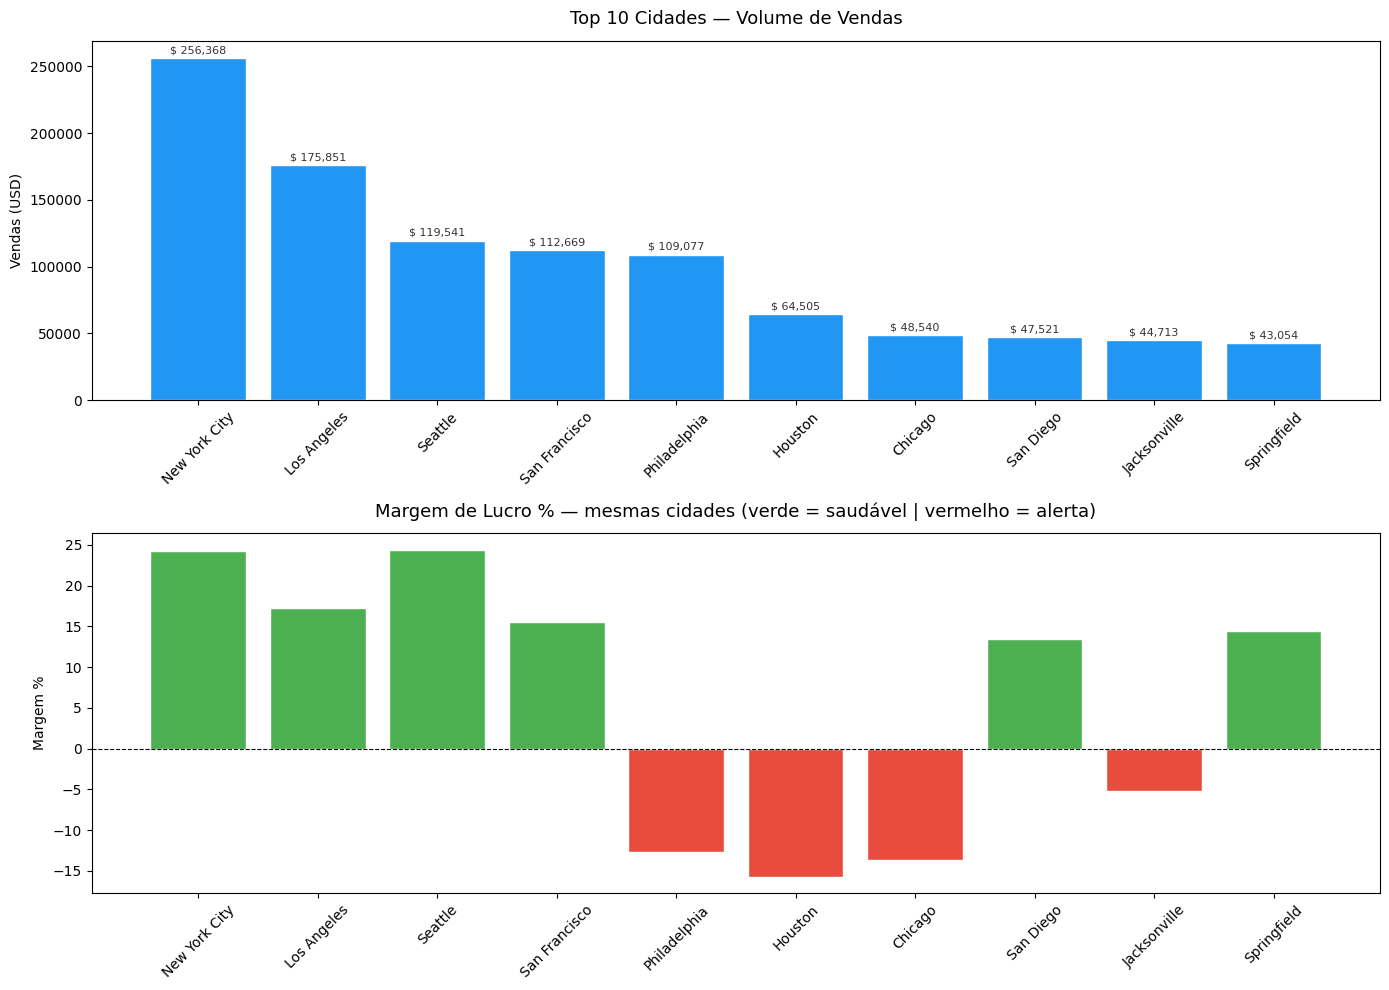

In [28]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico 1: Top 10 cidades por vendas
ax1.bar(top10.index, top10['Sales'], color='#2196F3', edgecolor='white')
ax1.set_title('Top 10 Cidades — Volume de Vendas', fontsize=13, pad=12)
ax1.set_ylabel('Vendas (USD)')
ax1.tick_params(axis='x', rotation=45)

# Adicionar valor em cima de cada barra
for i, (cidade_nome, valor) in enumerate(zip(top10.index, top10['Sales'])):
    ax1.text(i, valor + 2000, f'$ {valor:,.0f}', 
             ha='center', va='bottom', fontsize=8, color='#333333')

# Gráfico 2: Margem de lucro dessas mesmas cidades
cores = ['#e74c3c' if m < 5 else '#4CAF50' for m in top10['Margem %']]
ax2.bar(top10.index, top10['Margem %'], color=cores, edgecolor='white')
ax2.set_title('Margem de Lucro % — mesmas cidades (verde = saudável | vermelho = alerta)', fontsize=13, pad=12)
ax2.set_ylabel('Margem %')
ax2.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 3.2 Conclusões

> *Preencha após rodar a análise com os resultados reais encontrados.*

**Insight 1 — Subcategorias com prejuízo:**  
Tables e Bookcases são as subcategorias com maior prejuízo acumulado, mesmo 
figurando entre as mais vendidas. Isso indica que os descontos aplicados nessas 
categorias superam a margem do produto — uma oportunidade clara de revisão 
de política de preços.

**Insight 2 — Impacto do desconto:**  
A análise revela correlação negativa de -0.22 entre desconto e lucro — quanto 
maior o desconto concedido, menor o lucro gerado. Pedidos com desconto acima 
de 20% concentram a maioria dos prejuízos, evidenciando que a política de 
descontos atual impacta diretamente a rentabilidade do negócio.

**Insight 3 — Segmento mais lucrativo:**  
Apesar de representar o maior volume de vendas $1.161.401, o segmento 
Consumer tem a menor margem de lucro 11.5%. O segmento Home Office, embora 
com menor faturamento $429.653, apresenta a melhor margem 14%, sendo 
proporcionalmente o mais eficiente — um dado relevante para estratégias de 
foco comercial.

**Insight 4 — Qual cidade mais vende mas tem baixo lucro? (vendas altas mas margem baixa)**

New York City lidera em vendas ($ 256.368) com margem saudável de 24.2%. 
Porém Philadelphia e Houston, que estão entre o Top 6 em volume de vendas, 
operam com margens negativas de -12.7% e -15.7% respectivamente — ou seja, 
quanto mais vendem, mais prejuízo geram. Chicago segue o mesmo padrão 
com margem de -13.7%, sinalizando um problema estrutural nessas praças.
